# Lyman-alpha Reionization: First-Look Notebook

This notebook loads RT snapshots, plots ionization history, and computes a first bubble-size (MFP) distribution.

In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if (PROJECT_ROOT / 'src').exists():
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from lyman_alpha.data import list_snapshots, mean_ionized_fraction, load_ionized_fraction, parse_redshift
from lyman_alpha.bubble_stats import sample_mfp_distances

plt.rcParams['figure.figsize'] = (7, 4)

In [2]:
data_dir = PROJECT_ROOT / 'data' / 'for_aryana' / 'late_end_early_start'
snapshots = list_snapshots(data_dir)
len(snapshots), snapshots[0].name, snapshots[-1].name

(103, 'gas_z=04.7998', 'gas_z=17.3917')

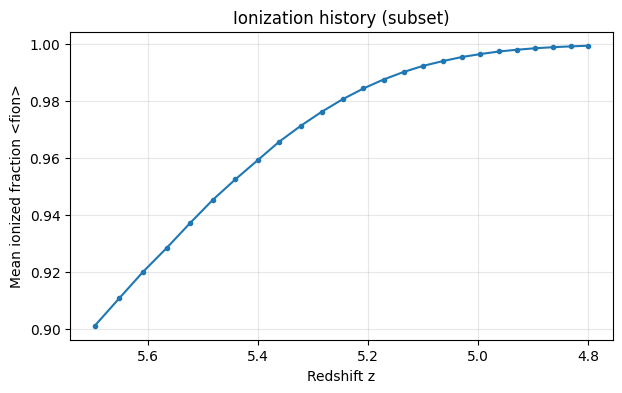

Closest in subset to x_HII=0.5: z=5.6971, <fion>=0.9012


In [3]:
# Quick first pass (set to None for all snapshots)
max_files = 25
stats = mean_ionized_fraction(snapshots[:max_files] if max_files else snapshots, n_grid=200)
z = np.array([a for a, _ in stats])
x = np.array([b for _, b in stats])

plt.plot(z, x, marker='o', ms=3)
plt.gca().invert_xaxis()
plt.xlabel('Redshift z')
plt.ylabel('Mean ionized fraction <fion>')
plt.title('Ionization history (subset)' if max_files else 'Ionization history (all snapshots)')
plt.grid(alpha=0.3)
plt.show()

target = 0.5
i = np.argmin(np.abs(x - target))
print(f'Closest in subset to x_HII={target}: z={z[i]:.4f}, <fion>={x[i]:.4f}')

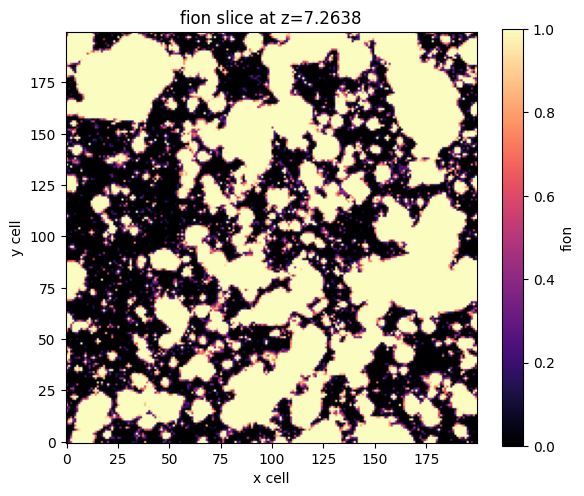

mean fion = 0.5651465654373169


In [4]:
# Pick a snapshot and inspect the ionized field
snap = snapshots[len(snapshots)//2]
fion = load_ionized_fraction(snap, n_grid=200, memmap=False)
z_snap = parse_redshift(snap)

mid = fion.shape[2] // 2
plt.figure(figsize=(6, 5))
im = plt.imshow(fion[:, :, mid], origin='lower', cmap='magma', vmin=0, vmax=1)
plt.colorbar(im, label='fion')
plt.title(f'fion slice at z={z_snap:.4f}')
plt.xlabel('x cell')
plt.ylabel('y cell')
plt.tight_layout()
plt.show()

print('mean fion =', float(fion.mean()))

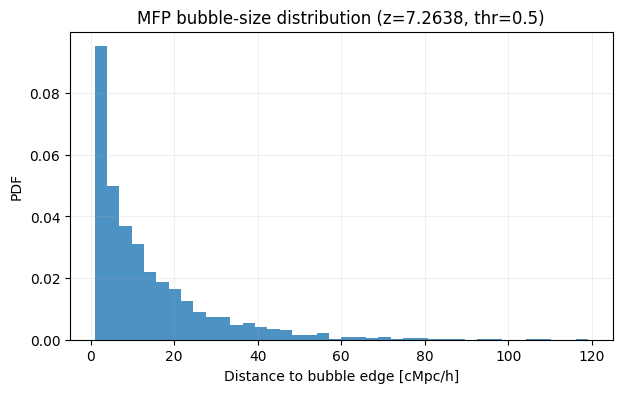

N distances: 3000
mean, median, p90: 13.613333702087402 8.5 32.5


In [5]:
# Bubble-size distribution via MFP method
threshold = 0.5
n_rays = 3000
mask = fion >= threshold

dist = sample_mfp_distances(mask, n_rays=n_rays, box_size_mpc_h=200.0, seed=42)

plt.hist(dist, bins=40, density=True, alpha=0.8)
plt.xlabel('Distance to bubble edge [cMpc/h]')
plt.ylabel('PDF')
plt.title(f'MFP bubble-size distribution (z={z_snap:.4f}, thr={threshold})')
plt.grid(alpha=0.2)
plt.show()

print('N distances:', len(dist))
print('mean, median, p90:', float(np.mean(dist)), float(np.median(dist)), float(np.quantile(dist, 0.9)))

In [6]:
# Optional: save one result file from notebook
out_dir = PROJECT_ROOT / 'results'
out_dir.mkdir(parents=True, exist_ok=True)
out = out_dir / f'notebook_mfp_z{z_snap:.4f}_thr{threshold:.2f}.npz'
np.savez(out, redshift=z_snap, threshold=threshold, distances_mpc_h=dist)
print('saved:', out)

saved: /home/aryana/Documents/GitHub/Lyman_alpha/results/notebook_mfp_z7.2638_thr0.50.npz
